In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models
from torch.onnx import export

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# onnxファイルを作成する関数
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file

In [3]:
# モデル読み込み
model = models.resnet18(weights = "IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 100)  # CIFAR-100 にあわせて出力層変更
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cuda


In [ ]:
# 訓練データセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

trainset = torchvision.datasets.CIFAR100(root = "../data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)

100%|██████████| 169M/169M [01:26<00:00, 1.95MB/s] 


In [5]:
# 訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
num_epochs = 15
epoch_loss_list = []

for epoch in range(num_epochs):
  model.train()
  total_loss = 0.0
  num_train = 0
  for inputs, labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)   # データ代入

    # 重み更新のための手順
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 損失を記録
    total_loss += loss.item()*labels.size(0)
    num_train+=labels.size(0)

  epoch_loss_list.append(total_loss/num_train)
  print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}')

  # early stop
  if epoch>0:
    if abs(epoch_loss_list[epoch]-epoch_loss_list[epoch-1])<0.001:
      print('early stop')
      break

Epoch[1/15], Loss: 2.5068
Epoch[2/15], Loss: 1.0719
Epoch[3/15], Loss: 0.6520
Epoch[4/15], Loss: 0.3970
Epoch[5/15], Loss: 0.2196
Epoch[6/15], Loss: 0.1099
Epoch[7/15], Loss: 0.0534
Epoch[8/15], Loss: 0.0288
Epoch[9/15], Loss: 0.0189
Epoch[10/15], Loss: 0.0130
Epoch[11/15], Loss: 0.0095
Epoch[12/15], Loss: 0.0075
Epoch[13/15], Loss: 0.0061
Epoch[14/15], Loss: 0.0051
early stop


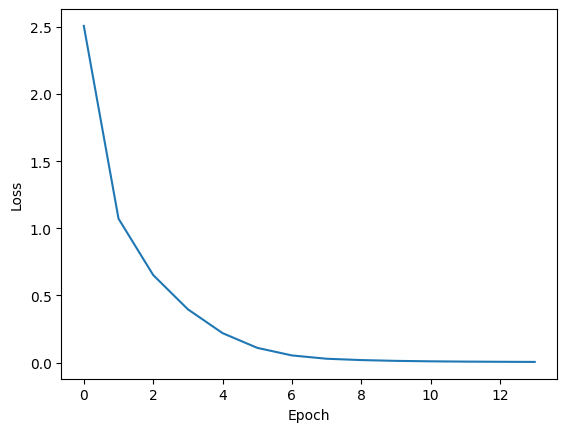

In [6]:
# 損失グラフ作成
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [7]:
# onnxファイルとptファイルの作成
model = model.to('cpu')
model_to_onnx(model, "dense_CIFAR100.onnx")
torch.save(model.state_dict(), "dense_CIFAR100.pt")